In [1]:
import torch
from torchvision.models import squeezenet1_0, SqueezeNet1_0_Weights
from torchvision.datasets import ImageFolder
from preprocess import ImagePreprocessor
import seaborn as sns
import matplotlib.pyplot as plt 

torch.manual_seed(36)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [2]:
train_data = "brain-Tumor-1/train"
test_data = "brain-Tumor-1/test"
val_data = "brain-Tumor-1/valid"

preprocessor = ImagePreprocessor(size=(227, 227))
train_dataset = ImageFolder(train_data, transform=preprocessor.train_transform)
test_dataset = ImageFolder(test_data, transform=preprocessor.test_transform)
val_dataset = ImageFolder(val_data, transform=preprocessor.test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

In [3]:
model = squeezenet1_0(weights=SqueezeNet1_0_Weights.DEFAULT)
print(model)

SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(96, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (5): Fire(
   

In [4]:
num_classes = len(train_dataset.classes)
model.classifier[1] = torch.nn.Conv2d(512, num_classes, kernel_size=(1, 1), stride=(1, 1))
model = model.to(device)

In [5]:
print(model)

SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(96, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (5): Fire(
   

In [6]:
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters left: {total_trainable_params}")

Total trainable parameters left: 736450


In [7]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier[1].parameters(), lr=0.001)
epochs = 50      

patience = 10
best_model_path = "models/squeezenet.pt"

best_val_loss = float("inf")
epochs_no_improve = 0

train_losses = []
val_losses = []

In [8]:
for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)

    model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs).squeeze()
            loss = criterion(outputs, labels)
            epoch_val_loss += loss.item()

    epoch_val_loss /= len(val_loader)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved → {best_model_path}  (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve}/{patience} epoch(s).")

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs.")
        break

print(f"Training complete. Best val loss: {best_val_loss:.4f}")

Epoch 1/50 | Train Loss: 1.0813 | Val Loss: 0.5923
Best model saved → models/squeezenet.pt  (val_loss=0.5923)
Epoch 2/50 | Train Loss: 0.8226 | Val Loss: 0.5842
Best model saved → models/squeezenet.pt  (val_loss=0.5842)
Epoch 3/50 | Train Loss: 0.7612 | Val Loss: 0.5443
Best model saved → models/squeezenet.pt  (val_loss=0.5443)
Epoch 4/50 | Train Loss: 0.6387 | Val Loss: 0.6110
  No improvement for 1/10 epoch(s).
Epoch 5/50 | Train Loss: 0.6290 | Val Loss: 0.6340
  No improvement for 2/10 epoch(s).
Epoch 6/50 | Train Loss: 0.5921 | Val Loss: 0.5680
  No improvement for 3/10 epoch(s).
Epoch 7/50 | Train Loss: 0.5401 | Val Loss: 0.4997
Best model saved → models/squeezenet.pt  (val_loss=0.4997)
Epoch 8/50 | Train Loss: 0.5282 | Val Loss: 0.4660
Best model saved → models/squeezenet.pt  (val_loss=0.4660)
Epoch 9/50 | Train Loss: 0.5399 | Val Loss: 0.4529
Best model saved → models/squeezenet.pt  (val_loss=0.4529)
Epoch 10/50 | Train Loss: 0.4856 | Val Loss: 0.4467
Best model saved → models/s

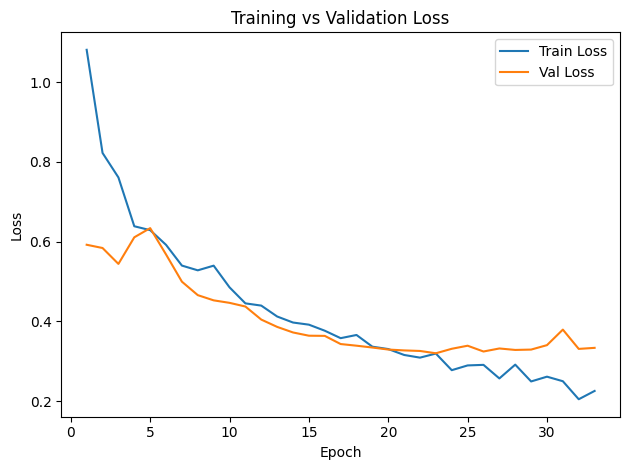

In [9]:
actual_epochs = range(1, len(train_losses) + 1)
sns.lineplot(x=actual_epochs, y=train_losses, label="Train Loss")
sns.lineplot(x=actual_epochs, y=val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("plots/loss_curve_sn.png")
plt.show()